In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy

print("✅ Imports ready")

✅ Imports ready


In [2]:
pew = pd.read_csv("../data/processed/pew_clean.csv")
llm = pd.read_csv("../data/processed/llm_responses.csv")

print(f"✅ Pew: {pew.shape}")
print(f"✅ LLM: {llm.shape}")
print(f"\nPew race counts:\n{pew['race'].value_counts()}")
print(f"\nLLM race counts:\n{llm['race'].value_counts()}")

✅ Pew: (5155, 11)
✅ LLM: (72, 5)

Pew race counts:
race
White       3442
Hispanic     631
Black        511
Other        371
Asian        200
Name: count, dtype: int64

LLM race counts:
race
White       18
Black       18
Hispanic    18
Asian       18
Name: count, dtype: int64


In [4]:
pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
from statsmodels.stats.proportion import proportions_ztest

print("=== Z-TEST: Are LLM responses significantly different from Pew? ===\n")

llm['llm_response'] = llm['llm_response'].astype(float)
pew['AIWRKOPPO_W157'] = pew['AIWRKOPPO_W157'].astype(float)

results = []

for race in ['White', 'Black', 'Hispanic', 'Asian']:
    pew_race = pew[pew['race'] == race]['AIWRKOPPO_W157'].dropna()
    pew_hurts = (pew_race >= 3).sum()
    pew_total = len(pew_race)
    
    llm_race = llm[llm['race'] == race]['llm_response'].dropna()
    llm_hurts = (llm_race >= 3).sum()
    llm_total = len(llm_race)
    
    count = np.array([llm_hurts, pew_hurts])
    nobs  = np.array([llm_total, pew_total])
    z, p  = proportions_ztest(count, nobs)
    
    results.append({
        'race': race,
        'pew_pct_hurt': round(pew_hurts/pew_total*100, 1),
        'llm_pct_hurt': round(llm_hurts/llm_total*100, 1),
        'z_score': round(z, 3),
        'p_value': round(p, 4),
        'significant': '✅ YES' if p < 0.05 else '❌ NO'
    })
    
    print(f"{race:10s}: Pew={pew_hurts/pew_total*100:.1f}% | LLM={llm_hurts/llm_total*100:.1f}% | p={p:.4f} | Significant: {'YES' if p < 0.05 else 'NO'}")

df_results = pd.DataFrame(results)

=== Z-TEST: Are LLM responses significantly different from Pew? ===

White     : Pew=59.9% | LLM=55.6% | p=0.7086 | Significant: NO
Black     : Pew=44.4% | LLM=77.8% | p=0.0054 | Significant: YES
Hispanic  : Pew=43.8% | LLM=61.1% | p=0.1471 | Significant: NO
Asian     : Pew=54.6% | LLM=61.1% | p=0.5968 | Significant: NO


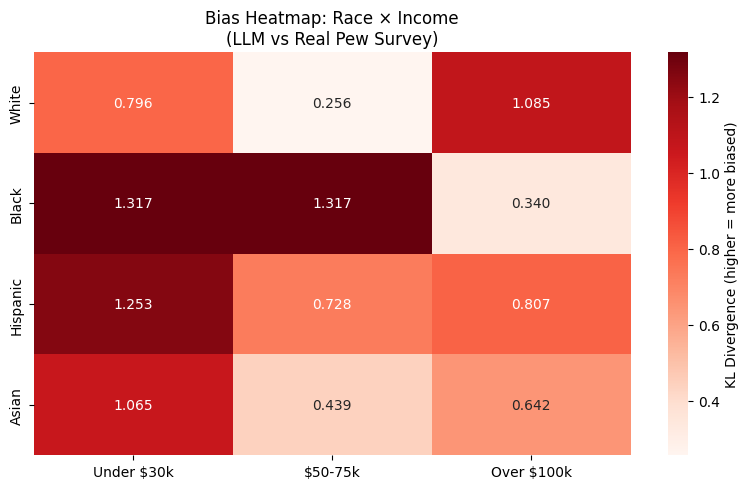

✅ Heatmap saved!


In [6]:
# KL Divergence across race AND income
RESPONSES = [1.0, 2.0, 3.0, 4.0]

def get_dist(df, group_col, group_val, response_col):
    subset = df[df[group_col] == group_val][response_col].dropna()
    counts = subset.value_counts()
    dist = np.array([counts.get(r, 0) for r in RESPONSES], dtype=float)
    dist = (dist + 1e-9) / dist.sum()
    return dist

races   = ['White', 'Black', 'Hispanic', 'Asian']
incomes = ['earning under $30k a year', 
           'earning $50,000-$75,000 a year', 
           'earning over $100k a year']

heatmap_data = []

for race in races:
    row = []
    for income in incomes:
        pew_sub = pew[pew['race'] == race]
        llm_sub = llm[(llm['race'] == race) & (llm['income'] == income)]
        
        real = get_dist(pew_sub, 'race', race, 'AIWRKOPPO_W157')
        llm_d = get_dist(llm_sub, 'race', race, 'llm_response')
        kl = entropy(llm_d, real)
        row.append(round(kl, 3))
    heatmap_data.append(row)

df_heat = pd.DataFrame(heatmap_data, 
                        index=races,
                        columns=['Under $30k', '$50-75k', 'Over $100k'])

plt.figure(figsize=(8, 5))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='Reds',
            cbar_kws={'label': 'KL Divergence (higher = more biased)'})
plt.title('Bias Heatmap: Race × Income\n(LLM vs Real Pew Survey)')
plt.tight_layout()
plt.savefig("../data/processed/bias_heatmap.png", dpi=150)
plt.show()
print("✅ Heatmap saved!")

In [7]:
df_results.to_csv("../data/processed/ztest_results.csv", index=False)
print("✅ Z-test results saved!")
print(df_results.to_string())

✅ Z-test results saved!
       race  pew_pct_hurt  llm_pct_hurt  z_score  p_value significant
0     White          59.9          55.6   -0.374   0.7086        ❌ NO
1     Black          44.4          77.8    2.779   0.0054       ✅ YES
2  Hispanic          43.8          61.1    1.450   0.1471        ❌ NO
3     Asian          54.6          61.1    0.529   0.5968        ❌ NO
